<a href="https://colab.research.google.com/github/juampamuc/notebooks/blob/main/MICCAI_2024_Education_Challenge_MedSAM_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MICCAI Educational Challenge 2024


Author: Misaal Khan
Affiliations: Medical Technologies, IIT-AIIMS Jodhpur Joint Program, India

Can use these materials for all purposes as long as the data licenses apply.



* [Official repo](https://github.com/bowang-lab/medsam)


# MEDSam: Medical Image Segmentation Using SAM

**Overview**:  
This notebook demonstrates how to use the **MEDSam** model for medical image segmentation. MEDSam leverages the Segment Anything Model (SAM) architecture but is trained specifically on medical imaging data, making it effective in handling tasks like organ segmentation, tumor identification, and other medical applications.

**Goals**:
- Understand how to set up MEDSam and use it for image segmentation.
- Explore image preprocessing, model inference, and visualization of segmentation results.
- Learn about the potential use cases of MEDSam in the medical domain.

**Applications**:
MEDSam can be used in a variety of healthcare and medical settings, including:
- **Organ segmentation**: Automated identification and segmentation of organs in radiology or pathology images.
- **Tumor detection**: Locating and segmenting tumors or other abnormalities within imaging studies.
- **Surgical planning**: Using segmentation to assist in pre-surgical planning by visualizing anatomical structures.

Let’s start by installing the necessary dependencies and setting up the environment.


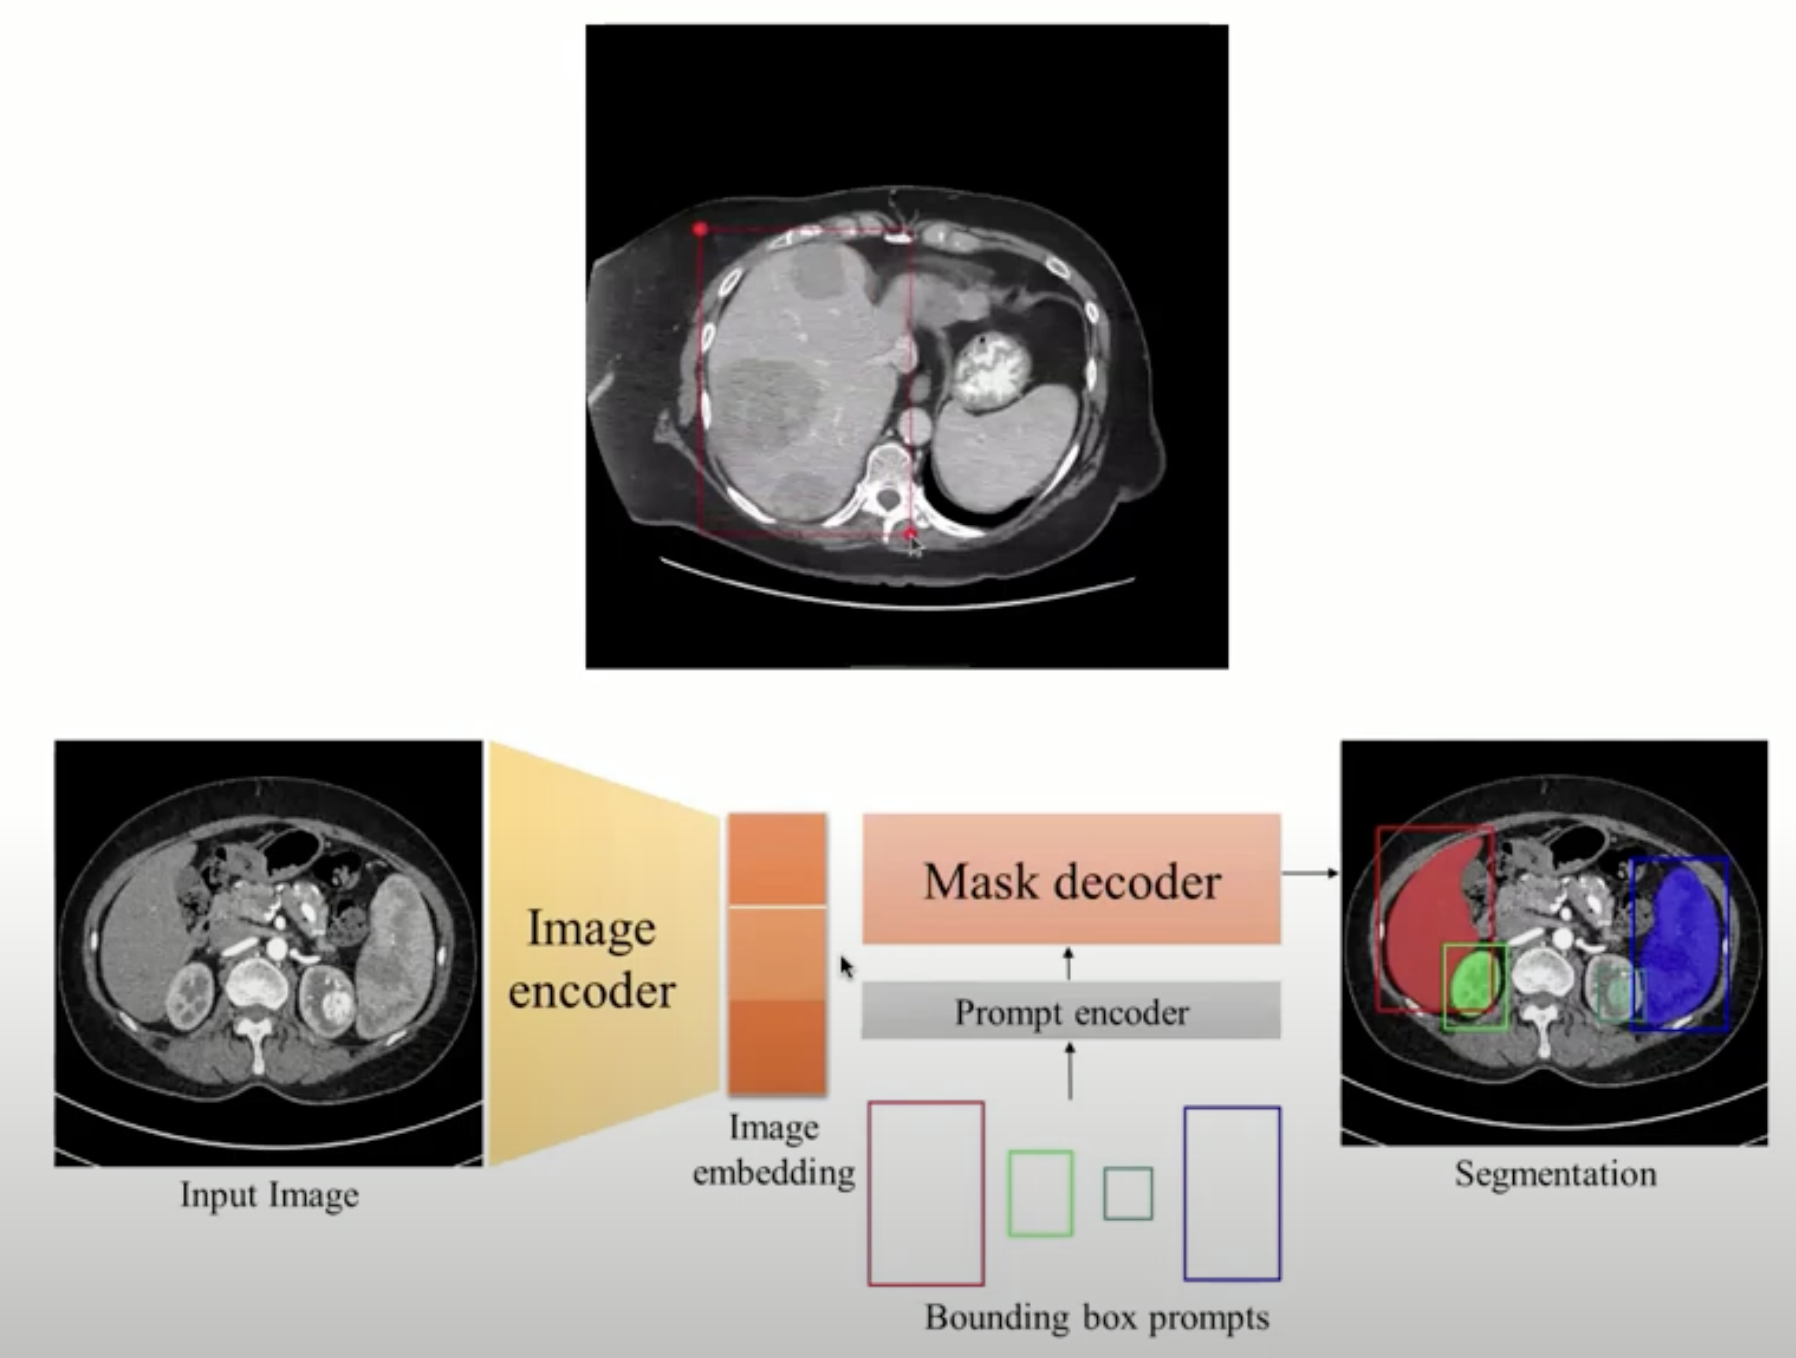

## Setup: Installing Dependencies and Cloning MEDSam

Before using MEDSam, we need to ensure that we have the necessary dependencies installed, including PyTorch and the MedSAM repository. This section will guide you through the installation process.

### Dependencies:
- **PyTorch**: A deep learning framework used for model inference.
- **scikit-image**: Used for image processing.
- **MedSAM**: The main repository that contains the model and associated utilities.

We will also clone the MedSAM repository from GitHub and download the model checkpoint for inference.


In [ ]:
# Install the MedSAM repository from GitHub and required dependencies
!pip install -q git+https://github.com/bowang-lab/MedSAM.git
!pip install -q torch torchvision scikit-image matplotlib

# Clone the repository for access to necessary scripts and resources
!git clone https://github.com/bowang-lab/MedSAM.git

# Ensure necessary directories exist for storing the model and other resources
import os
if not os.path.exists("medsam_model"):
    os.makedirs("medsam_model")

# Download the pretrained model checkpoint to the model directory
!wget -P medsam_model https://zenodo.org/record/10689643/files/medsam_vit_b.pth

# Download the example image for inference testing
!wget https://image.shutterstock.com/image-photo/medical-xray-diagnostic-brain-tomography-260nw-1923423025.jpg -O img_demo.png


  Preparing metadata (setup.py) ... done
fatal: destination path 'MedSAM' already exists and is not an empty directory.
--2024-08-18 06:12:47--  https://zenodo.org/record/10689643/files/medsam_vit_b.pth
Resolving zenodo.org (zenodo.org)... 188.185.79.172, 188.184.98.238, 188.184.103.159, ...
Connecting to zenodo.org (zenodo.org)|188.185.79.172|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/10689643/files/medsam_vit_b.pth [following]
--2024-08-18 06:12:47--  https://zenodo.org/records/10689643/files/medsam_vit_b.pth
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 375049145 (358M) [application/octet-stream]
Saving to: ‘medsam_model/medsam_vit_b.pth.1’

medsam_vit_b.pth.1  100%[===================>] 357.67M  52.3MB/s    in 4.5s    

2024-08-18 06:12:51 (79.8 MB/s) - ‘medsam_model/medsam_vit_b.pth.1’ saved [375049145/375049145]

--2024-08-18 06:12:51--  https://image.shutterstock.com/

## Step 3: Loading and Preparing the Model for Inference

Now that the necessary dependencies have been installed and the pretrained model has been downloaded, we can load the model into memory and prepare it for inference.

### What we will do:
1. Load the MedSAM model using the pretrained checkpoint (`medsam_vit_b.pth`).
2. Load a sample medical image for testing.
3. Preprocess the image so that it's compatible with the model, including resizing and normalizing the image.


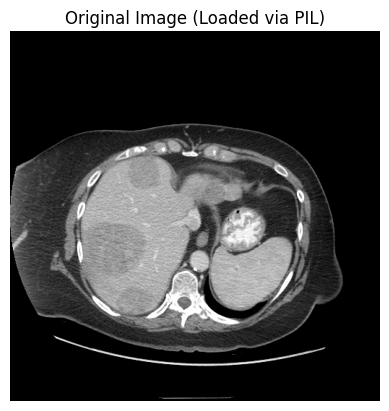

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry
import numpy as np

# Set the path to the model checkpoint and specify the device (GPU or CPU)
checkpoint_path = "medsam_model/medsam_vit_b.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the MedSAM model from the checkpoint
medsam_model = sam_model_registry["vit_b"](checkpoint=checkpoint_path)
medsam_model = medsam_model.to(device)
medsam_model.eval()  # Set the model to evaluation mode

# Load the example image using PIL
image_path = "img_demo.png"
img_pil = Image.open(image_path).convert("RGB")  # Convert to RGB to ensure consistency
img_np = np.array(img_pil)

# Get the image dimensions
H, W, _ = img_np.shape

# Display the original image
plt.imshow(img_np)
plt.title("Original Image (Loaded via PIL)")
plt.axis("off")
plt.show()


## Step 4: Image Preprocessing and Model Inference

Now that we have successfully loaded the image and the model, we need to preprocess the image for inference. This includes:
1. Resizing the image to 1024x1024 pixels.
2. Normalizing the image so that the pixel values are between 0 and 1.
3. Converting the image into a format that the MedSAM model can process (PyTorch tensor).
4. Running inference on the preprocessed image to generate a segmentation mask.


In [ ]:
@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    # Convert the bounding box to a torch tensor
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)

    # Adjust shape if needed
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :]  # (B, 1, 4)

    # Get sparse and dense embeddings for the bounding box
    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )

    # Get low resolution mask predictions
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed,  # (B, 256, 64, 64)
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),  # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings,  # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings,  # (B, 256, 64, 64)
        multimask_output=False,
    )

    # Apply sigmoid to get the probability mask
    low_res_pred = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)

    # Resize the prediction to match the original image size
    low_res_pred = F.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )  # (1, 1, H, W)

    # Squeeze and convert the prediction to a numpy array
    low_res_pred = low_res_pred.squeeze().cpu().numpy()  # (H, W)

    # Apply thresholding to get the final segmentation mask
    medsam_seg = (low_res_pred > 0.5).astype(np.uint8)

    return medsam_seg


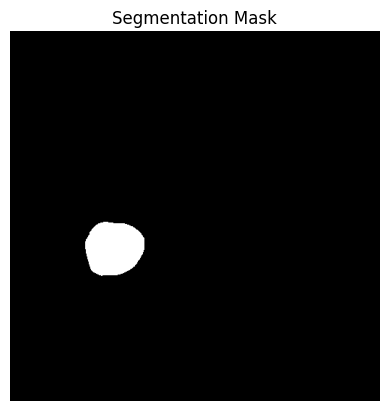

In [ ]:
from skimage import transform
import torch.nn.functional as F

# Resize the image to 1024x1024 for the model
img_1024 = transform.resize(img_np, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True).astype(np.float32)

# Normalize the image
img_1024 = (img_1024 - img_1024.min()) / np.clip(img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None)

# Convert the image to a tensor and move to the appropriate device (CPU or GPU)
img_1024_tensor = torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(device)

# Define the bounding box for the area to be segmented (example box)
box_np = np.array([[95, 255, 190, 350]])  # Example bounding box (modify as needed)

# Scale the bounding box to match the 1024x1024 resized image
box_1024 = box_np / np.array([W, H, W, H]) * 1024

# Perform inference with the MedSAM model
with torch.no_grad():
    image_embedding = medsam_model.image_encoder(img_1024_tensor)  # (1, 256, 64, 64)

# Use the medsam_inference function from the previous step
medsam_seg = medsam_inference(medsam_model, image_embedding, box_1024, H, W)

# Display the segmentation result
plt.imshow(medsam_seg, cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")
plt.show()
